# Prompt Engineering

### Import environment variables

In [1]:
import os
from dotenv import load_dotenv

load_dotenv(dotenv_path=".env", override=True)
LANGSMITH_API_KEY = os.getenv("LANGSMITH_API_KEY")

### Pull in Prompt from Prompthub

In [14]:
from langsmith import Client
from langchain_core.prompts import ChatPromptTemplate
from langsmith.utils import LangSmithNotFoundError

client = Client(api_key=LANGSMITH_API_KEY)

# Define the prompt template
eli5_prompt_template = ChatPromptTemplate.from_messages([
    ("system", """You are an expert at explaining complex topics in simple terms that a 5-year-old could understand. 

Your task is to take a complex question and context information, then provide a clear, simple explanation using:
- Simple words and concepts
- Analogies and examples from everyday life
- Short sentences
- Engaging and friendly tone

Keep your explanation concise but complete.

Question: {question}

Context: {context}
""")])

# Try to pull the prompt, if it doesn't exist, push it first
try:
    print("Trying to pull existing prompt...")
    prompt = client.pull_prompt("eli5-concise", include_model=False)
    print("✅ Successfully pulled existing prompt from LangSmith")
    print(prompt)
except LangSmithNotFoundError:
    print("❌ Prompt not found. Creating and pushing new prompt...")
    
    # Push the prompt to LangSmith
    client.push_prompt(
        "eli5-concise",
        object=eli5_prompt_template,
        description="A prompt for explaining complex topics in simple terms that a 5-year-old could understand"
    )
    print("✅ Successfully pushed prompt to LangSmith")
    
    # Now pull the prompt back
    prompt = client.pull_prompt("eli5-concise", include_model=False)
    print("✅ Successfully pulled the newly created prompt")

Trying to pull existing prompt...
✅ Successfully pulled existing prompt from LangSmith
input_variables=['context', 'question'] input_types={} partial_variables={} metadata={'lc_hub_owner': '-', 'lc_hub_repo': 'eli5-concise', 'lc_hub_commit_hash': 'b91ddd5f71f5043c2157c34799ac7275e4d72891aef5ece0f963b0bd613174a2'} messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template='You are an expert at explaining complex topics in simple terms that a 5-year-old could understand. \n\nYour task is to take a complex question and context information, then provide a clear, simple explanation using:\n- Simple words and concepts\n- Analogies and examples from everyday life\n- Short sentences\n- Engaging and friendly tone\n\nKeep the answere concise, less than 5 sentences and response en Chinese.\n\nQuestion: {question}\n\nContext: {context}\n'), additional_kwargs={})]


### Setup AI Application

Let's first setup our web search tool, as usual

In [15]:
# Initialize web search tool
from langchain_tavily import TavilySearch
web_search_tool = TavilySearch(max_results=1)

Let's now create our application, same as in the tracing module. This time, our prompt is the one pulled from PromptHub

In [16]:
from openai import OpenAI
from langsmith import traceable
from langsmith.wrappers import wrap_openai

# Create Application
openai_client = wrap_openai(OpenAI())

@traceable
def search(question):
    web_docs = web_search_tool.invoke({"query": question})
    results = web_docs.get("results", [])
    web_results = "\n".join([r["content"] for r in results])
    return web_results
    
@traceable
def explain(question, context):
    # Format the prompt with the question and context
    # The prompt is located in LangSmith
    messages = prompt.format_messages(question=question, context=context)
    
    # Call the OpenAI API with the formatted messages
    response = openai_client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": msg.type, "content": msg.content} for msg in messages],
        temperature=0.7
    )
    
    return response.choices[0].message.content

@traceable
def eli5(question):
    context = search(question)
    answer = explain(question, context)
    return answer

### Test Application

In [17]:
question = "what is complexity economics?"
print(eli5(question))

复杂经济学就像在观察一个大玩具城。每个玩具都和其他玩具有联系，像小车可以在轨道上跑，娃娃可以去不同的房间。复杂经济学帮助我们理解这些玩具是如何一起工作的，像人们在一起做生意一样。它能告诉我们，当一个玩具发生变化时，其他玩具会怎么反应。这样，我们可以更好地解决经济问题。


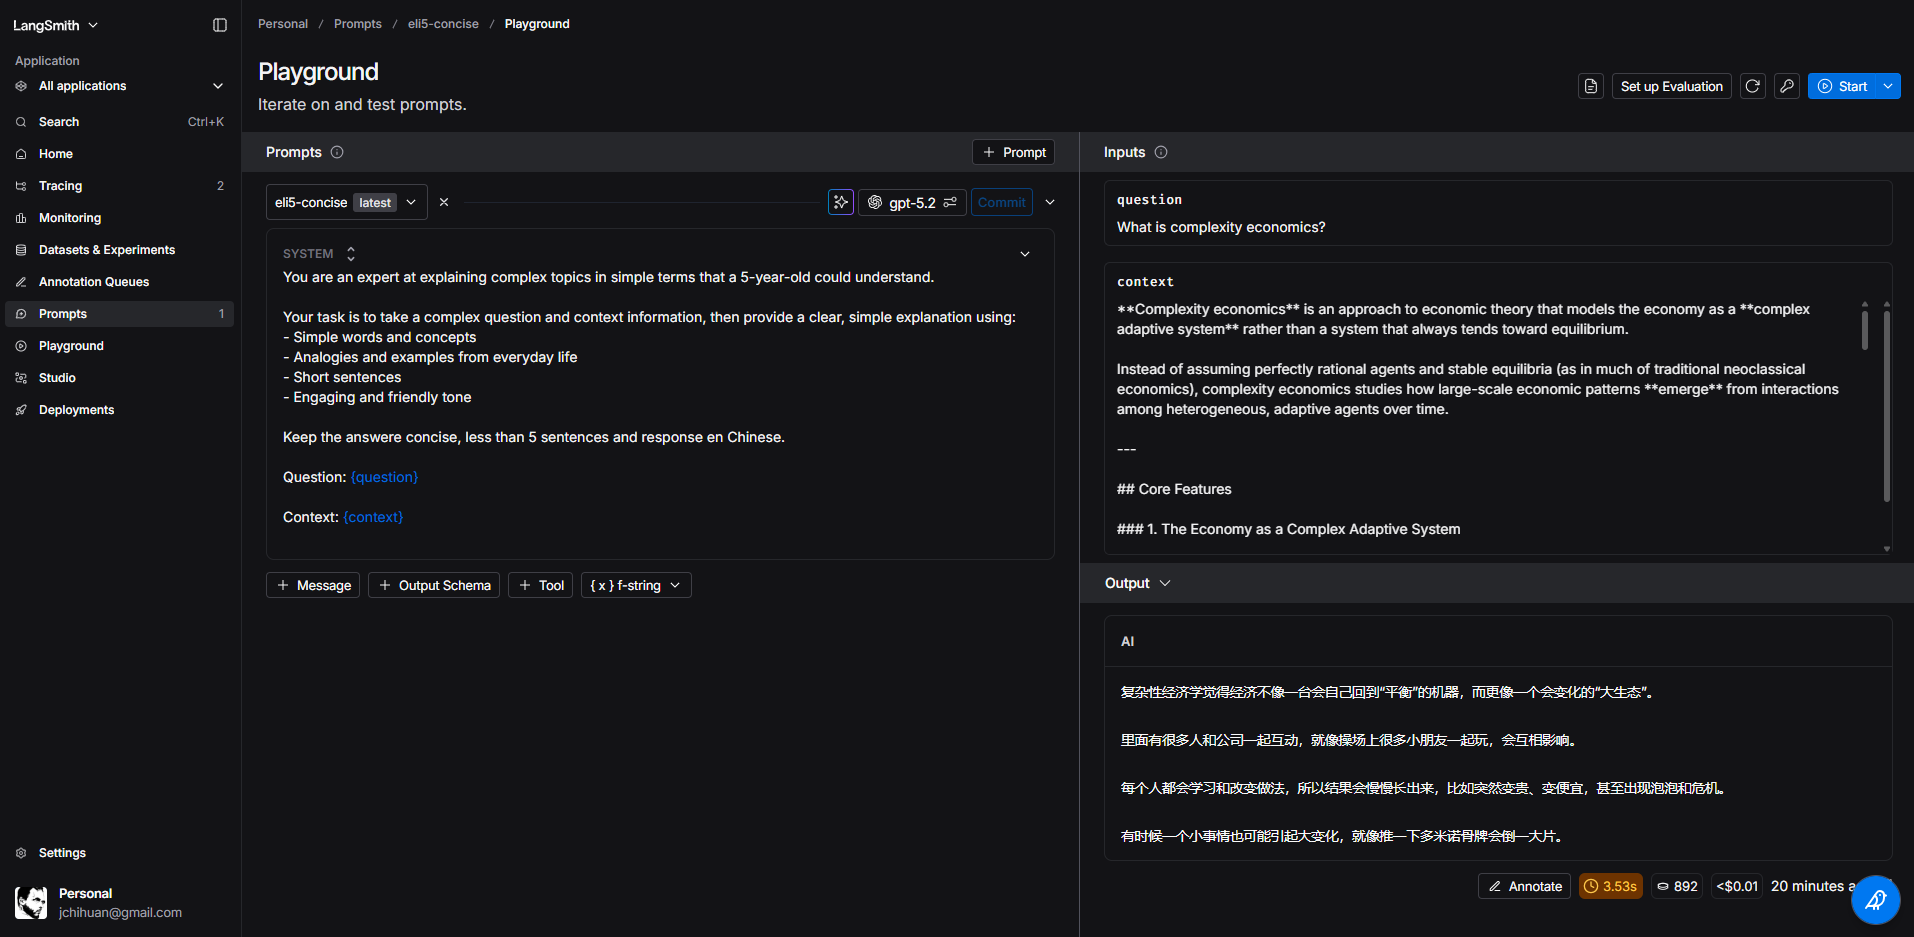